In [1]:
import argparse
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import gaussian_kde



In [2]:

# ─────────────────────────────────────────────
# GLOBAL STYLE
# ─────────────────────────────────────────────

PALETTE = {
    'h_total':      '#C0392B',   # deep red
    'margin':       '#E67E22',   # amber
    'h_tau':        '#2980B9',   # steel blue
    'h_tau_ccrc':   '#27AE60',   # forest green — proposed
    'h_total_ccrc': '#8E44AD',   # purple
    'margin_ccrc':  '#16A085',   # teal
}
LABELS = {
    'h_total':      'H_Total (Global)',
    'margin':       'Margin (Global)',
    'h_tau':        'H_tau (Global)',
    'h_tau_ccrc':   'H_tau + CCRC (Proposed)',
    'h_total_ccrc': 'H_Total + CCRC',
    'margin_ccrc':  'Margin + CCRC',
}
DISEASE_MARKERS = {
    'MS': {'tau': 0.11, 'color': '#8E44AD', 'marker': 'D'},
    'PD': {'tau': 0.29, 'color': '#16A085', 'marker': 's'},
    'AD': {'tau': 0.54, 'color': '#E67E22', 'marker': '^'},
}


In [3]:
# load rejection curve data for synth data: tau = 0.05, d= 0.5, n=300
synth_rejection_curves = pd.read_csv('../data/synthetic_results/rejection_curves.csv')

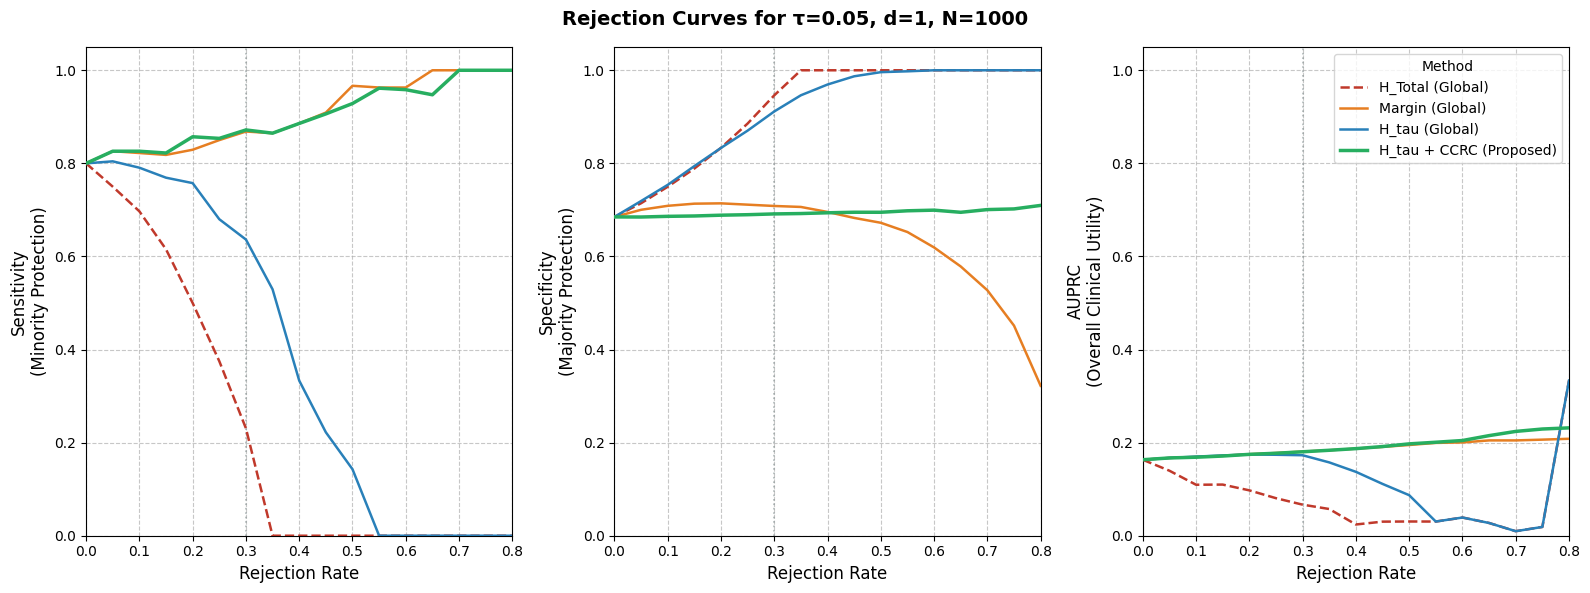

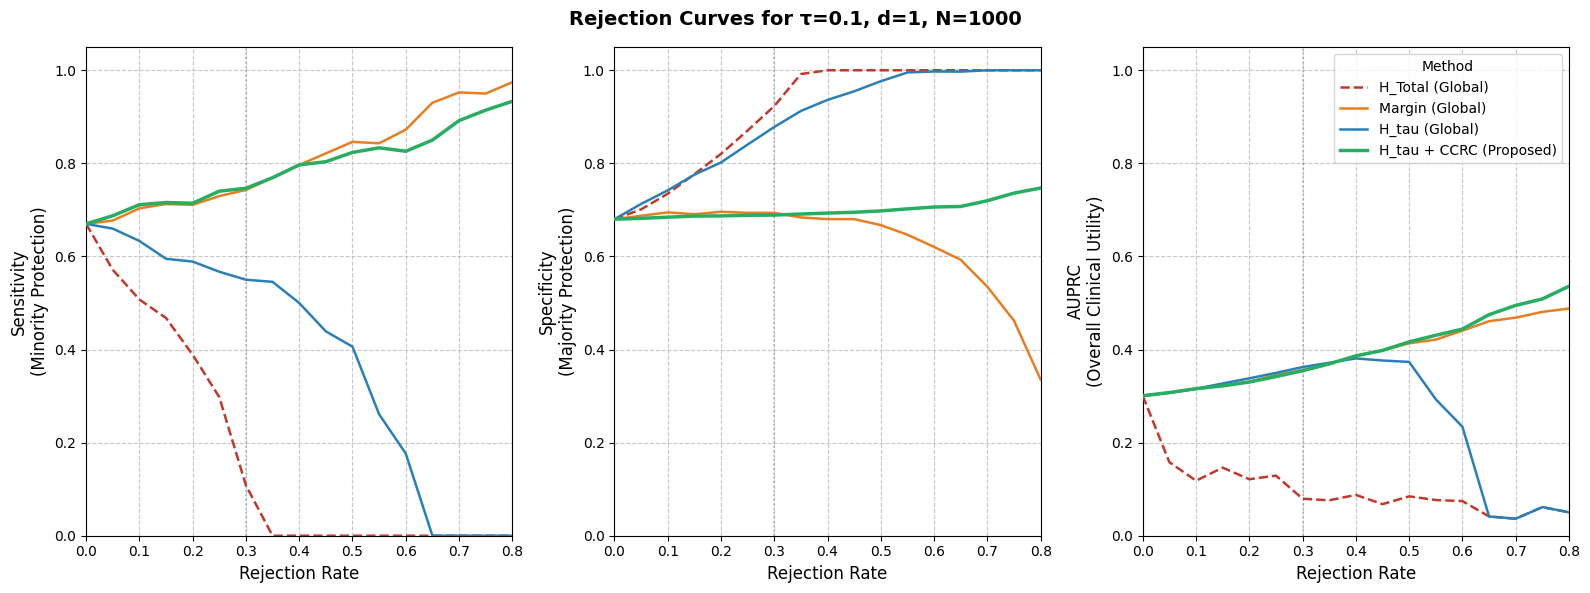

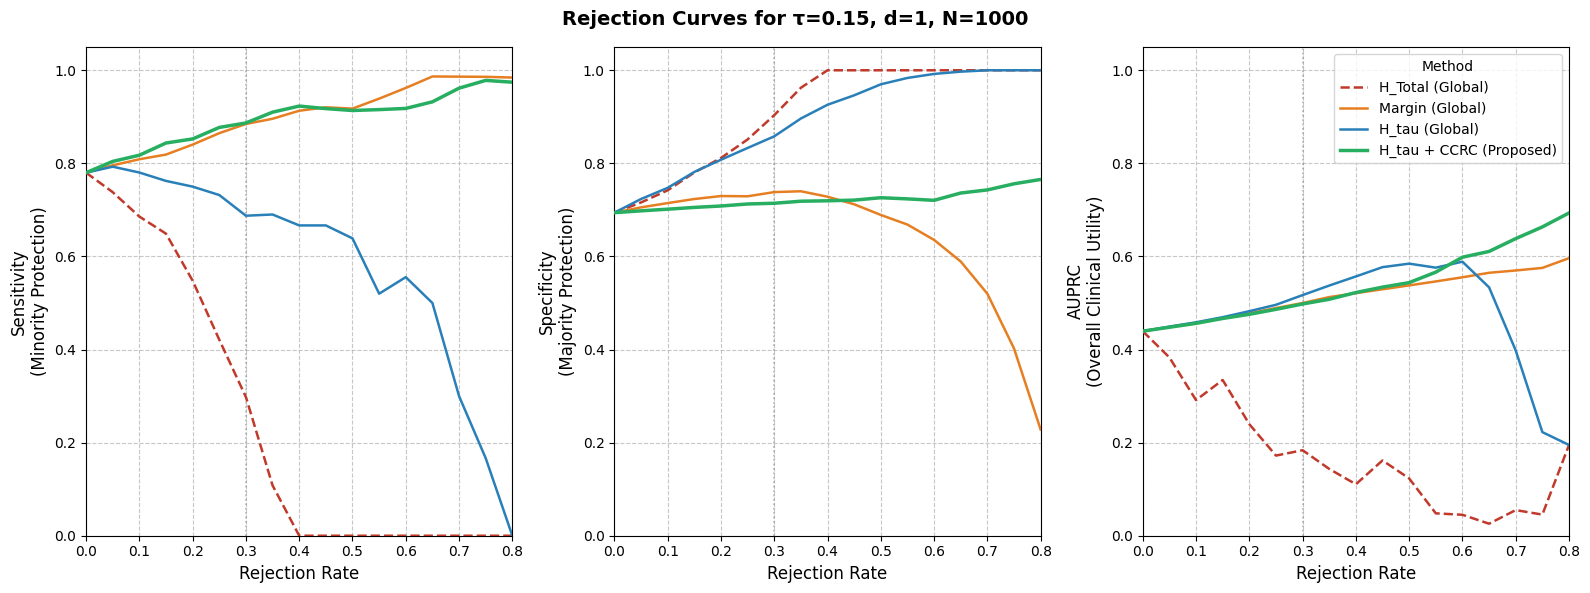

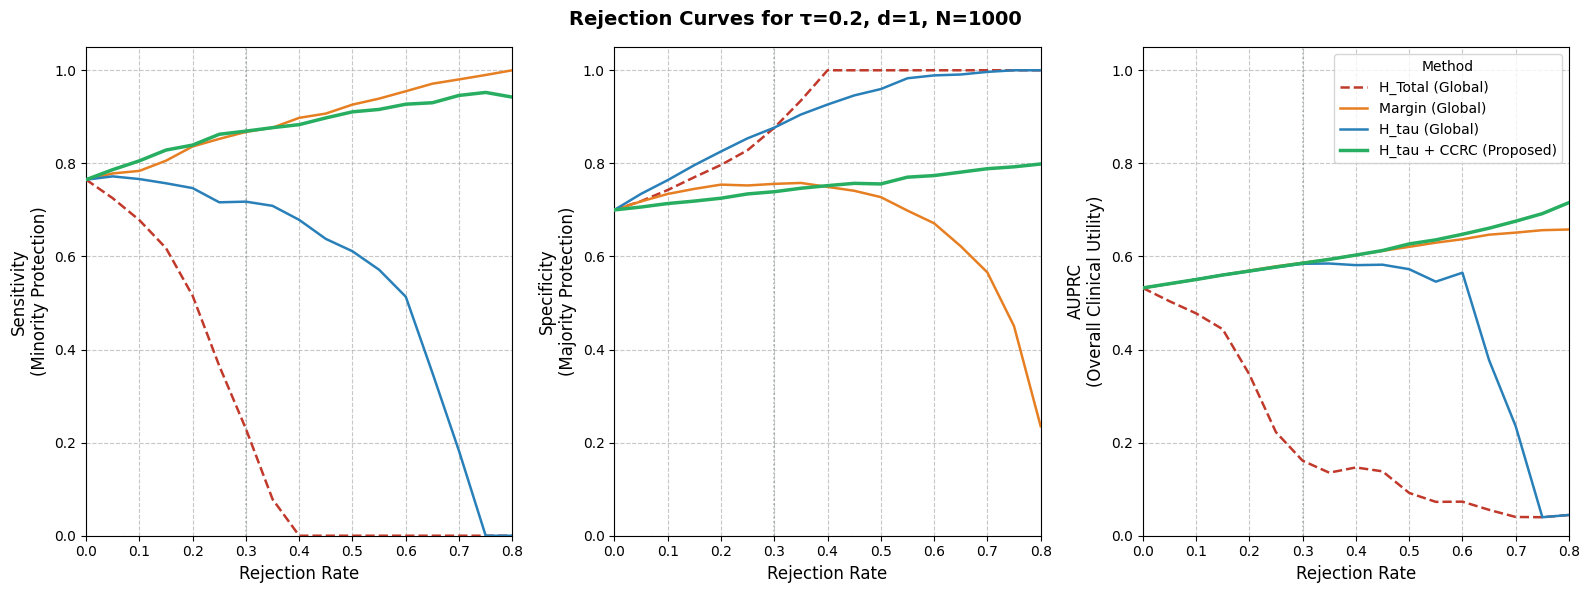

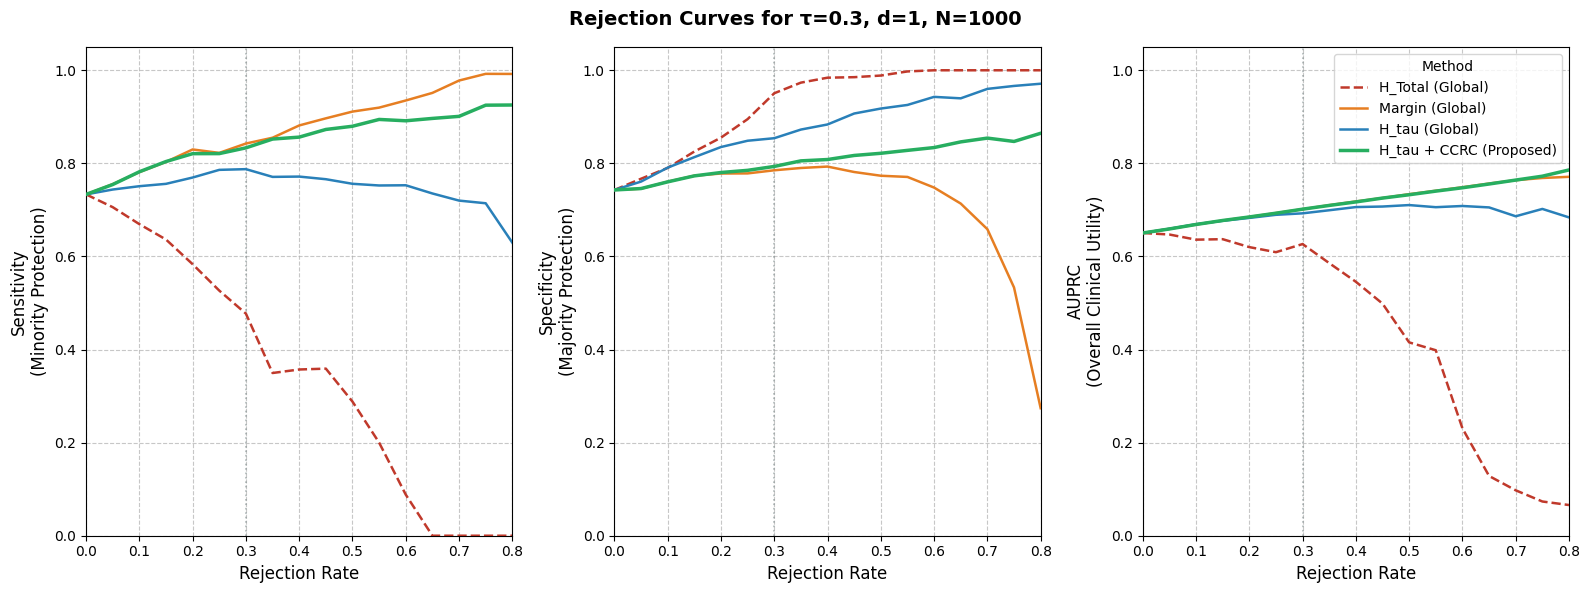

In [4]:
d = 1
n = 1000
taus = [0.05, 0.10, 0.15, 0.20, 0.30]
for tau in taus:
    curves = synth_rejection_curves.query(f"tau == {tau} & d == {d} & n == {n}").copy()
    curves.sort_values('rejection_rate', inplace=True)
    curves
    metrics = [
        ('sensitivity', 'Sensitivity\n(Minority Protection)'),
        ('specificity', 'Specificity\n(Majority Protection)'),
        ('auprc',       'AUPRC\n(Overall Clinical Utility)'),
    ]
    methods_to_show = ['h_total', 'margin', 'h_tau', 'h_tau_ccrc']

    fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=True)
    fig.suptitle(f'Rejection Curves for τ={tau}, d={d}, N={n}', fontsize=14, fontweight='bold')

    for ax, (metric, ylabel) in zip(axes, metrics):
        for method in methods_to_show:
            sub = curves[curves['method'] == method].sort_values('rejection_rate')
            ls = '--' if method == 'h_total' else '-'
            lw = 2.5 if method == 'h_tau_ccrc' else 1.8
            ax.plot(
                sub['rejection_rate'], sub[metric],
                color=PALETTE.get(method, None),
                label=LABELS.get(method, method),
                linewidth=lw, linestyle=ls, zorder=3
            )

        ax.axvline(0.30, color='#7F8C8D', ls=':', lw=1.2, alpha=0.6)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(0, 0.80)
        ax.grid(True, linestyle='--', alpha=0.7)

        ax.set_xlabel('Rejection Rate', fontsize=12)
    axes[2].legend(title='Method', fontsize=10, loc='upper right')

    plt.tight_layout()
    plt.show()
    plt.close()


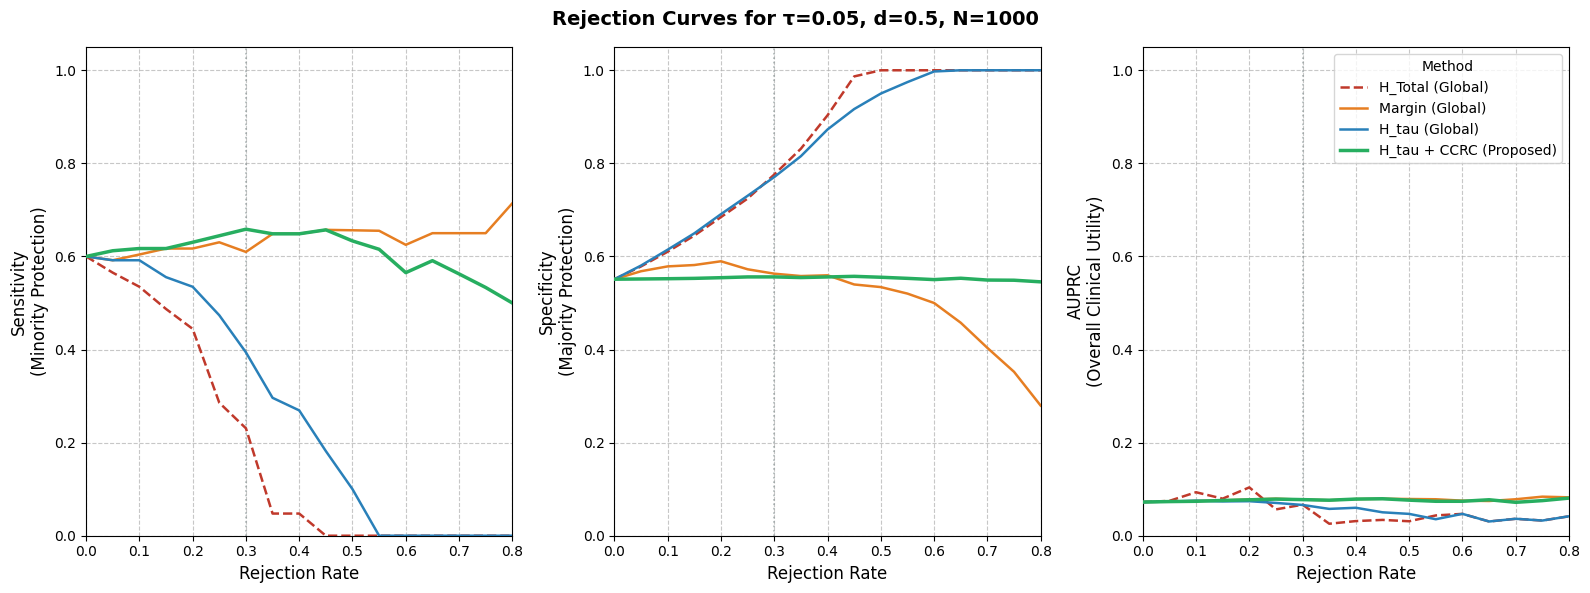

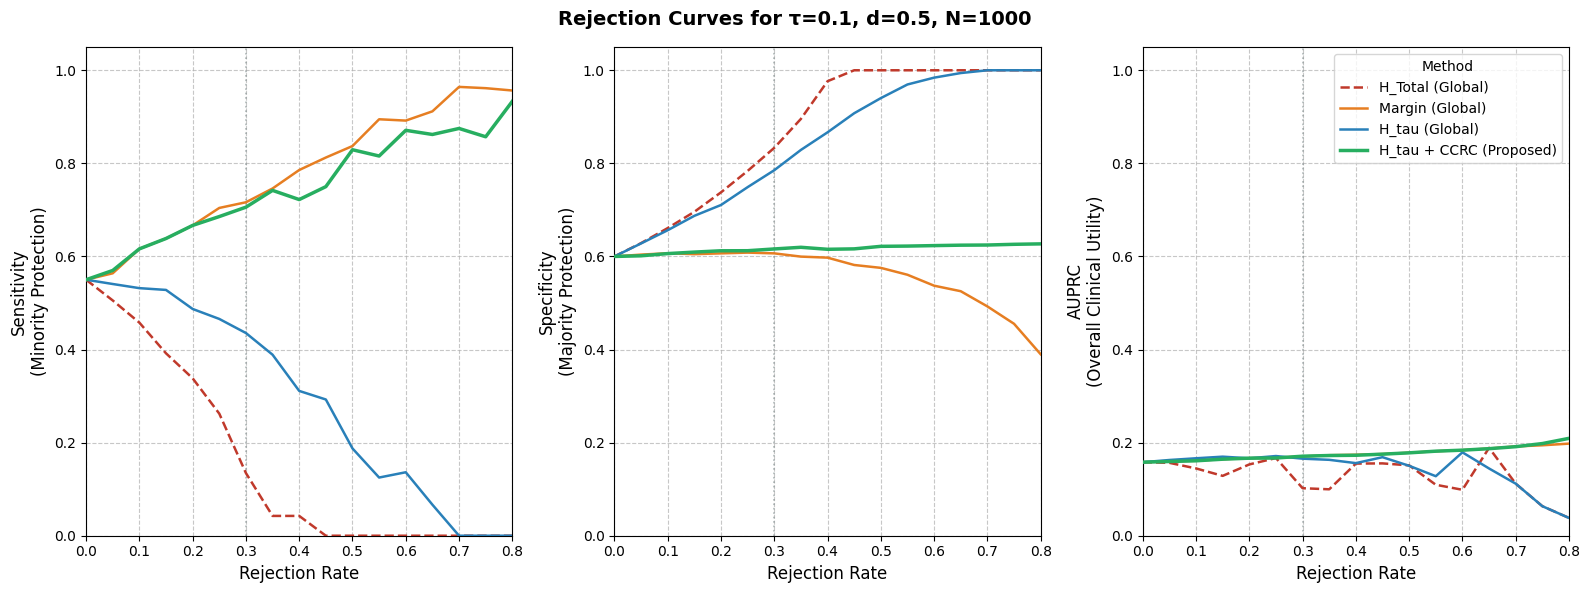

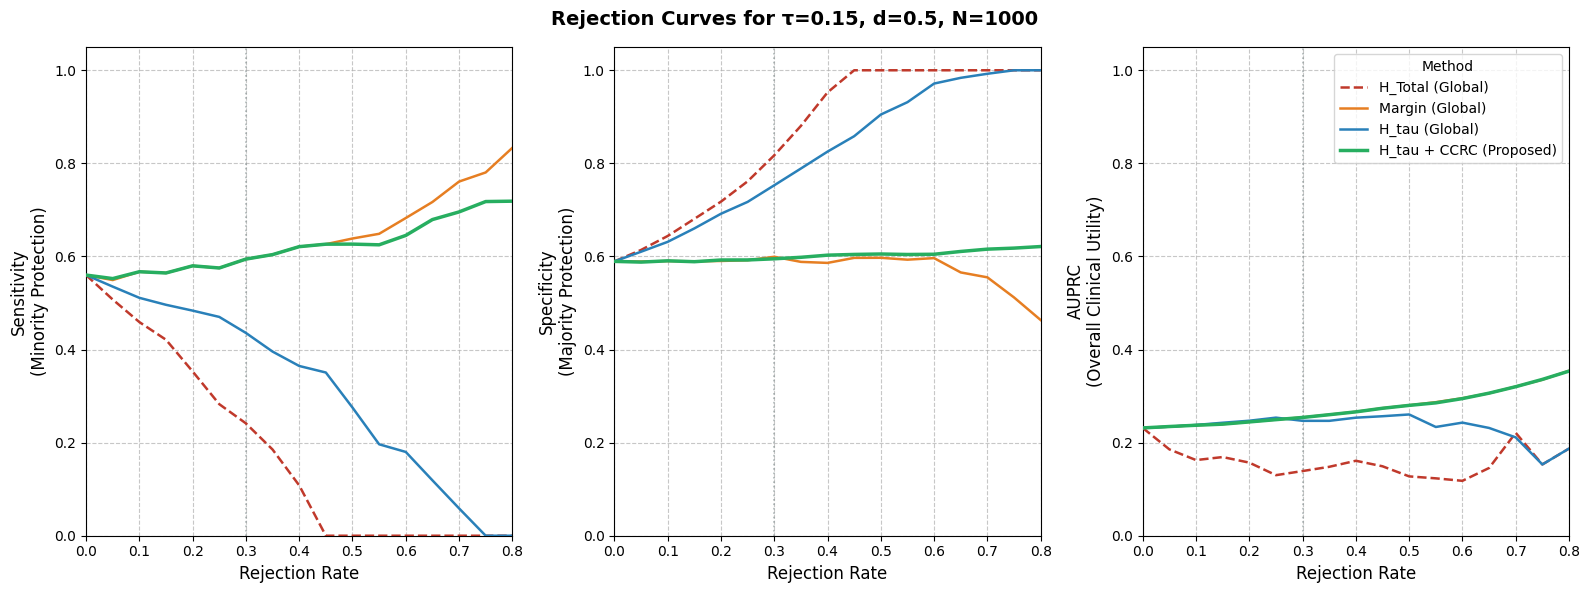

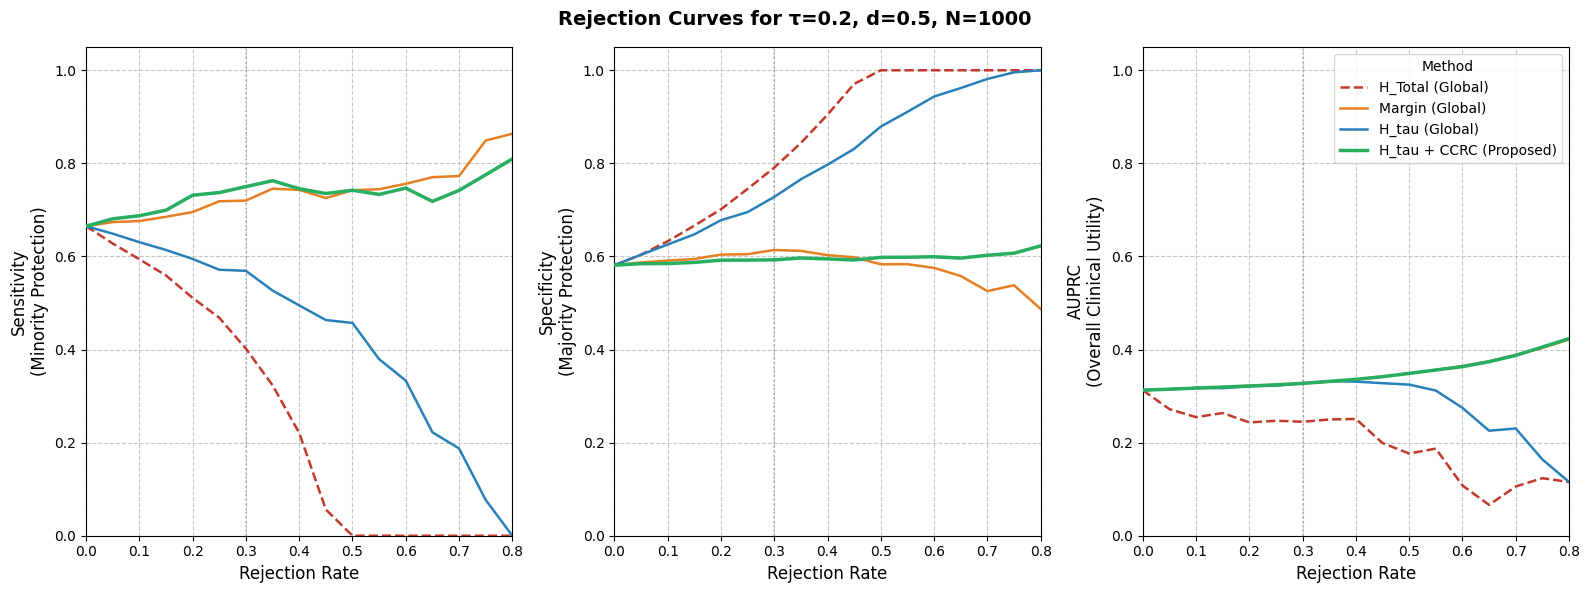

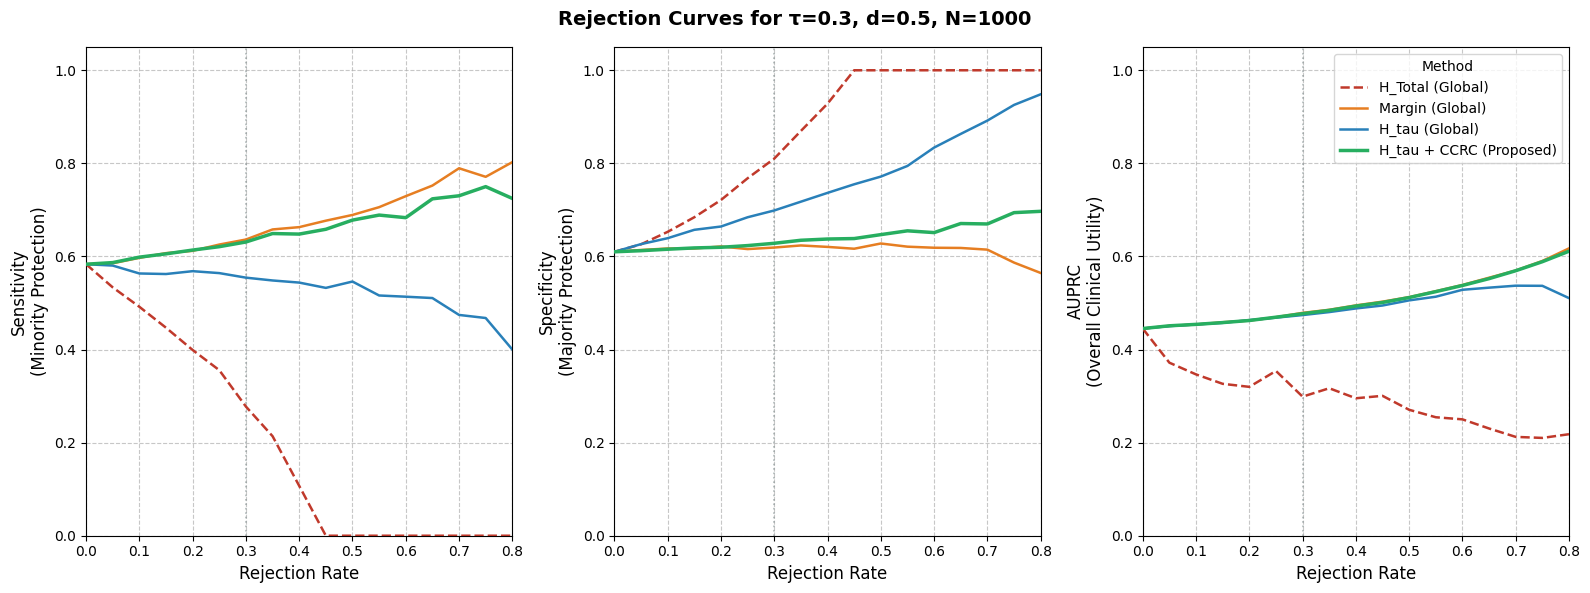

In [5]:
d = 0.5
n = 1000
taus = [0.05, 0.10, 0.15, 0.20, 0.30]
for tau in taus:
    curves = synth_rejection_curves.query(f"tau == {tau} & d == {d} & n == {n}").copy()
    curves.sort_values('rejection_rate', inplace=True)
    curves
    metrics = [
        ('sensitivity', 'Sensitivity\n(Minority Protection)'),
        ('specificity', 'Specificity\n(Majority Protection)'),
        ('auprc',       'AUPRC\n(Overall Clinical Utility)'),
    ]
    methods_to_show = ['h_total', 'margin', 'h_tau', 'h_tau_ccrc']

    fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=True)
    fig.suptitle(f'Rejection Curves for τ={tau}, d={d}, N={n}', fontsize=14, fontweight='bold')

    for ax, (metric, ylabel) in zip(axes, metrics):
        for method in methods_to_show:
            sub = curves[curves['method'] == method].sort_values('rejection_rate')
            ls = '--' if method == 'h_total' else '-'
            lw = 2.5 if method == 'h_tau_ccrc' else 1.8
            ax.plot(
                sub['rejection_rate'], sub[metric],
                color=PALETTE.get(method, None),
                label=LABELS.get(method, method),
                linewidth=lw, linestyle=ls, zorder=3
            )

        ax.axvline(0.30, color='#7F8C8D', ls=':', lw=1.2, alpha=0.6)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(0, 0.80)
        ax.grid(True, linestyle='--', alpha=0.7)

        ax.set_xlabel('Rejection Rate', fontsize=12)
    axes[2].legend(title='Method', fontsize=10, loc='upper right')

    plt.tight_layout()
    plt.show()
    plt.close()
